# Random Forest + Gaussian Mixture Model (GMM)
## Breast Cancer Wisconsin (Diagnostic) — my analysis

### Questions I wanted to answer
1. **Supervised:** Can a Random Forest predict benign (B) vs malignant (M) tumours from the 30 nuclear-morphology measurements?
2. **Interpretation:** Which measurements contribute most to the Random Forest predictions?
3. **Unsupervised:** If I hide the diagnosis labels, does a GMM recover groups related to benign/malignant status?

I keep the same preprocessing decisions as our group notebook: remove `id`, encode B=0/M=1, and use the same stratified 80/20 split (`random_state=42`) for supervised evaluation.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, adjusted_rand_score,
                             normalized_mutual_info_score, silhouette_score)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 40)


## 1. Load the data and reproduce our common preprocessing
I first verify that I am working with the expected dataset. The modelling features are the 30 morphology measurements; `id` is excluded because it is only an identifier.


In [ ]:
# Reproducible data loading
# Use breast_cancer.csv when it is available; otherwise rebuild the same
# Wisconsin diagnostic dataset from scikit-learn so "Run all" works cleanly.
from pathlib import Path
import numpy as np
import pandas as pd

def load_project_data():
    candidates = [
        Path("breast_cancer.csv"),
        Path("/content/breast_cancer.csv"),
        Path("/mnt/data/breast_cancer.csv"),
    ]
    for path in candidates:
        if path.exists():
            data = pd.read_csv(path)
            data.columns = data.columns.str.strip()
            if {"id", "diagnosis"}.issubset(data.columns):
                print(f"Loaded: {path}")
                return data

    from sklearn.datasets import load_breast_cancer
    raw = load_breast_cancer(as_frame=True)
    features = raw.data.copy()

    def project_name(name):
        if name.startswith("mean "):
            return name[5:].replace(" ", "_") + "_mean"
        if name.endswith(" error"):
            return name[:-6].replace(" ", "_") + "_se"
        if name.startswith("worst "):
            return name[6:].replace(" ", "_") + "_worst"
        return name.replace(" ", "_")

    features.columns = [project_name(c) for c in features.columns]
    data = features.copy()
    data.insert(0, "id", np.arange(1, len(data) + 1))
    data.insert(1, "diagnosis", np.where(raw.target.to_numpy() == 0, "M", "B"))
    print("breast_cancer.csv not found; loaded the equivalent scikit-learn dataset.")
    return data

df = load_project_data()
print("Dataset shape:", df.shape)

print("Diagnosis counts:", df["diagnosis"].value_counts())
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"B": 0, "M": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Training set:", X_train.shape, "| Test set:", X_test.shape)


### Why I kept the outliers
The common preprocessing notebook flags extreme values with the IQR rule but does not automatically remove them. I keep that choice: extreme morphology can be real biological information, especially in malignant samples. Random Forest is also relatively insensitive to feature scale. For GMM I standardize the variables because its probabilistic geometry is scale-sensitive.


# Part A — Random Forest (supervised)
A Random Forest combines many decision trees. Each tree sees a bootstrap sample and random subsets of features, and the forest combines their predictions. I chose it because it can model nonlinear relationships/interactions and also provides feature-importance measures.


## 2. Start with a simple baseline Random Forest
Before tuning, I fit a basic forest. This gives me a reference point, so tuning has a clear purpose rather than jumping directly to an optimized model.


In [ ]:
baseline_rf = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced'
)
baseline_rf.fit(X_train, y_train)
baseline_prob = baseline_rf.predict_proba(X_test)[:, 1]
baseline_pred = baseline_rf.predict(X_test)
print('Baseline test accuracy:', round(accuracy_score(y_test, baseline_pred), 4))
print('Baseline test ROC-AUC:', round(roc_auc_score(y_test, baseline_prob), 4))


Baseline test accuracy: 0.9649
Baseline test ROC-AUC: 0.996


## 3. Fit the selected Random Forest
The final hyperparameters are fixed here to keep this notebook reproducible and efficient. Cross-validation robustness is reported centrally in Notebook 05.


In [ ]:
best_rf = RandomForestClassifier(
    n_estimators=500, max_depth=8, max_features="sqrt",
    min_samples_leaf=1, random_state=RANDOM_STATE, class_weight="balanced",
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
print("Selected parameters: n_estimators=500, max_depth=8, max_features=sqrt, min_samples_leaf=1")


## 4. Final Random Forest performance on unseen test samples
I now evaluate the selected model once on the 20% test set. In this project, malignant is the positive class (`1`), so false negatives are malignant samples predicted as benign.


In [ ]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics_rf = pd.Series({
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Sensitivity (Recall)': recall_score(y_test, y_pred),
    'Specificity': tn/(tn+fp),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
})
print(metrics_rf.round(4))
print(f'\nTN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'Correct predictions: {tn+tp}/{len(y_test)}')


Accuracy                0.9737
Precision               1.0000
Sensitivity (Recall)    0.9286
Specificity             1.0000
F1-score                0.9630
ROC-AUC                 0.9967
dtype: float64

TN=72, FP=0, FN=3, TP=39
Correct predictions: 111/114


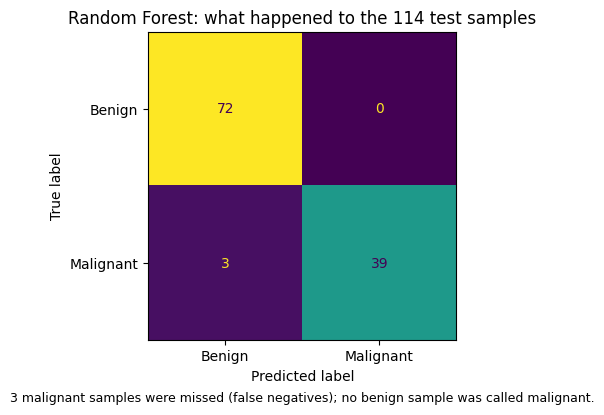

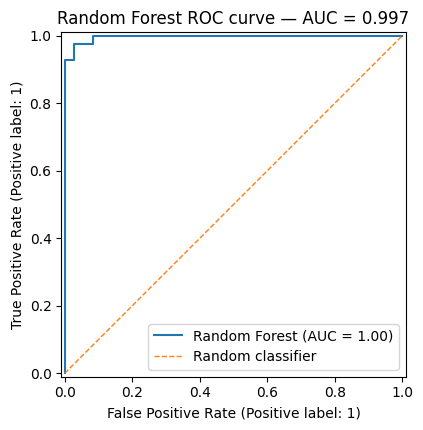

In [ ]:
fig, ax = plt.subplots(figsize=(5.2,4.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Benign', 'Malignant'], ax=ax, colorbar=False
)
ax.set_title('Random Forest: what happened to the 114 test samples')
ax.text(0.5, -0.20, '3 malignant samples were missed (false negatives); no benign sample was called malignant.',
        transform=ax.transAxes, ha='center', fontsize=9)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5.4,4.4))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name='Random Forest')
ax.plot([0,1],[0,1],'--',linewidth=1,label='Random classifier')
ax.set_title(f'Random Forest ROC curve — AUC = {metrics_rf["ROC-AUC"]:.3f}')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


### My interpretation
The model correctly classified **111/114** test samples. All **72 benign** samples were identified correctly, while **39/42 malignant** samples were detected and **3 malignant cases were missed**. The ROC-AUC is about **0.997**, showing very strong discrimination on this held-out split. The false negatives are important to mention because missing a malignant case is more concerning than the overall accuracy alone suggests.


## 5. Check for overfitting
A forest can fit the training data extremely well, so I compare training and test performance. A perfect training score does not prove the model is bad, but the train–test gap should be acknowledged.


          Training    Test
Accuracy       1.0  0.9737
ROC-AUC        1.0  0.9967


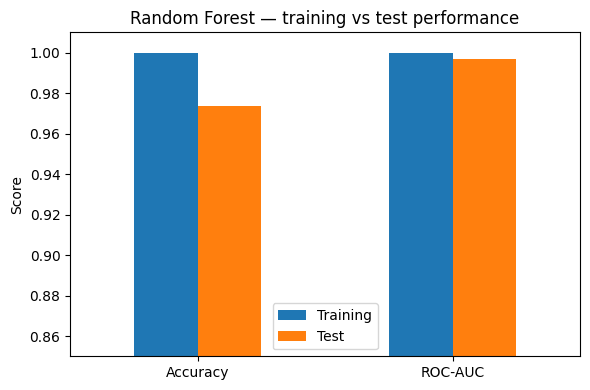

In [ ]:
train_pred = best_rf.predict(X_train)
train_prob = best_rf.predict_proba(X_train)[:,1]
comparison = pd.DataFrame({
    'Training':[accuracy_score(y_train,train_pred), roc_auc_score(y_train,train_prob)],
    'Test':[accuracy_score(y_test,y_pred), roc_auc_score(y_test,y_prob)]
}, index=['Accuracy','ROC-AUC'])
print(comparison.round(4))

comparison.plot(kind='bar', figsize=(6,4), ylim=(0.85,1.01))
plt.ylabel('Score'); plt.title('Random Forest — training vs test performance')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


**What I notice:** training performance is perfect, while test performance remains very high. This indicates some train–test gap, so I would not claim the model is universally perfect. The test set is small and there is no external validation dataset.


## 6. Which features matter?
I first inspect the Random Forest's built-in mean-decrease-in-impurity (MDI) importance. Then I add **permutation importance on the test set** as a useful cross-check: if shuffling one feature reduces ROC-AUC, that feature was helping prediction.


Top 10 MDI features: perimeter_worst         0.1359
area_worst              0.1307
concave_points_worst    0.1129
concave_points_mean     0.1002
radius_worst            0.0847
radius_mean             0.0522
perimeter_mean          0.0514
concavity_mean          0.0507
concavity_worst         0.0390
area_mean               0.0381
dtype: float64


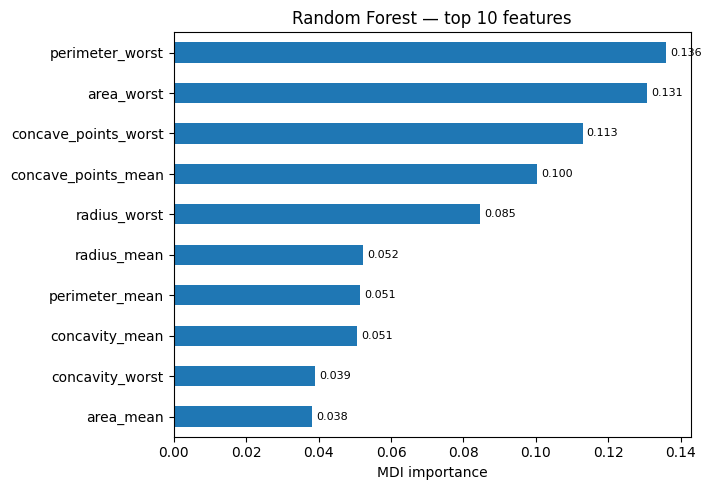

In [ ]:
mdi = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Top 10 MDI features:', mdi.head(10).round(4))

fig, ax = plt.subplots(figsize=(7.2,5))
mdi.head(10).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('MDI importance')
ax.set_title('Random Forest — top 10 features')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout(); plt.show()


Top permutation-importances (test ROC-AUC): area_worst                0.0063
concave_points_worst      0.0054
perimeter_worst           0.0025
radius_worst              0.0014
texture_worst             0.0008
concavity_worst           0.0007
concave_points_mean       0.0007
texture_mean              0.0001
fractal_dimension_mean    0.0000
fractal_dimension_se     -0.0001
dtype: float64


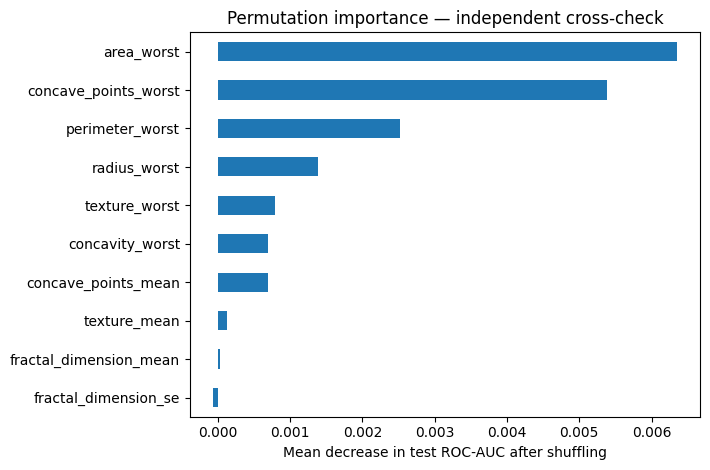

In [ ]:
perm = permutation_importance(
    best_rf, X_test, y_test, n_repeats=3, random_state=RANDOM_STATE,
    scoring='roc_auc', n_jobs=1
)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print('Top permutation-importances (test ROC-AUC):', perm_imp.head(10).round(4))

fig, ax = plt.subplots(figsize=(7.2,4.8))
perm_imp.head(10).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Mean decrease in test ROC-AUC after shuffling')
ax.set_title('Permutation importance — independent cross-check')
plt.tight_layout(); plt.show()


### Feature interpretation
The strongest MDI variables are dominated by **size** (`perimeter`, `area`, `radius`) and **concavity/concave-point** measurements, especially `worst` measurements. Permutation importance gives a second view and again highlights several of these variables. Because many breast-morphology variables are correlated, importance can be shared between predictors; these plots describe **predictive contribution, not biological causality**.


# Part B — Gaussian Mixture Model (unsupervised)
For GMM I deliberately do **not** use the diagnosis labels during fitting. The question is different from Random Forest: do the 30 measurements contain natural grouping structure related to diagnosis?


## 7. Standardize the 30 features
GMM is scale-sensitive, so I standardize the variables before clustering. For this exploratory unsupervised analysis I use all 569 samples and only compare clusters with diagnosis **after** fitting.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled matrix:', X_scaled.shape)
print('Mean of scaled values:', round(float(X_scaled.mean()), 4))
print('Overall SD:', round(float(X_scaled.std()), 4))


Scaled matrix: (569, 30)
Mean of scaled values: -0.0
Overall SD: 1.0


## 8. How many Gaussian components does the data prefer?
I compare 1–6 components with BIC and AIC. **Lower is better.** This is important because I should not automatically assume that two diagnoses imply exactly two Gaussian components.


   Components      BIC      AIC
0           1  48823.2  48562.6
1           2  37876.9  37351.3
2           3  35697.8  34907.2
3           4  33792.0  32736.4
4           5  32334.7  31014.2
5           6  31126.0  29540.5
Lowest BIC among 1–6 components: 6


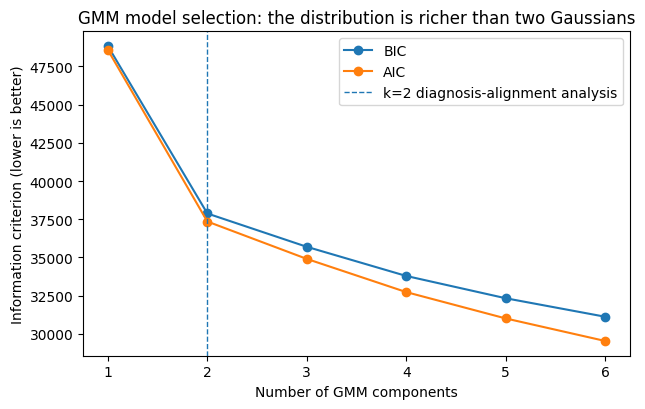

In [ ]:
rows = []
for k in range(1, 7):
    g = GaussianMixture(n_components=k, covariance_type='diag', n_init=3, random_state=RANDOM_STATE)
    g.fit(X_scaled)
    rows.append({'Components': k, 'BIC': g.bic(X_scaled), 'AIC': g.aic(X_scaled)})
ic = pd.DataFrame(rows)
print(ic.round(1))
print('Lowest BIC among 1–6 components:', int(ic.loc[ic.BIC.idxmin(), 'Components']))

fig, ax = plt.subplots(figsize=(6.5,4.2))
ax.plot(ic['Components'], ic['BIC'], marker='o', label='BIC')
ax.plot(ic['Components'], ic['AIC'], marker='o', label='AIC')
ax.axvline(2, linestyle='--', linewidth=1, label='k=2 diagnosis-alignment analysis')
ax.set_xlabel('Number of GMM components'); ax.set_ylabel('Information criterion (lower is better)')
ax.set_title('GMM model selection: the distribution is richer than two Gaussians')
ax.legend(); plt.tight_layout(); plt.show()


### Important observation
BIC and AIC keep decreasing through **k=6** in this tested range. Therefore, I **do not claim that k=2 is the statistically optimal GMM**. I fit a separate two-component GMM specifically to answer the biological comparison question: *if I ask for two unsupervised groups, how well do they correspond to the two known diagnoses?* The decreasing information criteria suggest additional heterogeneity inside the data.


## 9. Two-component GMM: compare discovered groups with diagnosis


In [13]:
gmm = GaussianMixture(n_components=2, covariance_type='diag', n_init=10, random_state=RANDOM_STATE)
clusters = gmm.fit_predict(X_scaled)

ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)
sil = silhouette_score(X_scaled, clusters)
cross = pd.crosstab(pd.Series(y, name='Diagnosis'), pd.Series(clusters, name='GMM cluster'))
cross.index = ['Benign (0)', 'Malignant (1)']

print('ARI:', round(ari,4))
print('NMI:', round(nmi,4))
print('Silhouette:', round(sil,4))
print('Cluster sizes:', pd.Series(clusters).value_counts().sort_index().to_dict())
print("\nDiagnosis vs GMM cluster:")
print(cross)


ARI: 0.6779
NMI: 0.5603
Silhouette: 0.3157
Cluster sizes: {0: 345, 1: 224}

Diagnosis vs GMM cluster:
GMM cluster      0    1
Benign (0)     326   31
Malignant (1)   19  193


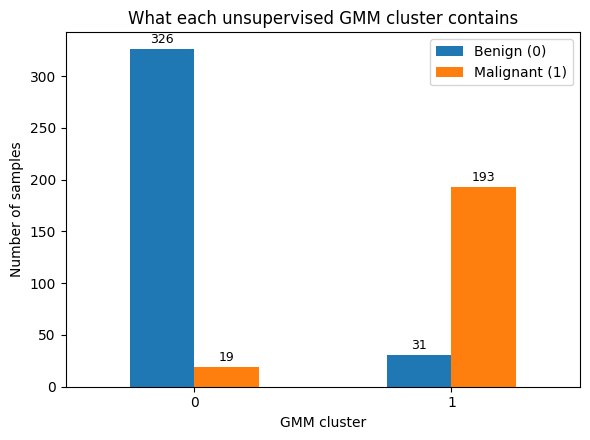

In [14]:
fig, ax = plt.subplots(figsize=(6,4.5))
cross.T.plot(kind='bar', ax=ax)
ax.set_xlabel('GMM cluster'); ax.set_ylabel('Number of samples')
ax.set_title('What each unsupervised GMM cluster contains')
ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)
plt.tight_layout(); plt.show()


### My interpretation
Cluster 0 contains **326 benign + 19 malignant** samples, while cluster 1 contains **31 benign + 193 malignant** samples. The ARI (**0.678**) and NMI (**0.560**) show meaningful but imperfect agreement with diagnosis. The silhouette score (**0.316**) is consistent with overlap rather than two perfectly separated clouds. Importantly, cluster labels 0/1 are arbitrary; I compare their composition rather than treating the cluster number itself as a diagnosis.


## 10. PCA visualization of the GMM result
The original clustering uses all 30 standardized features. PCA is used **only to visualize** those samples in two dimensions; it is not the space used to fit the GMM.


PC1 explains 44.3%; PC2 explains 19.0%; together 63.2%


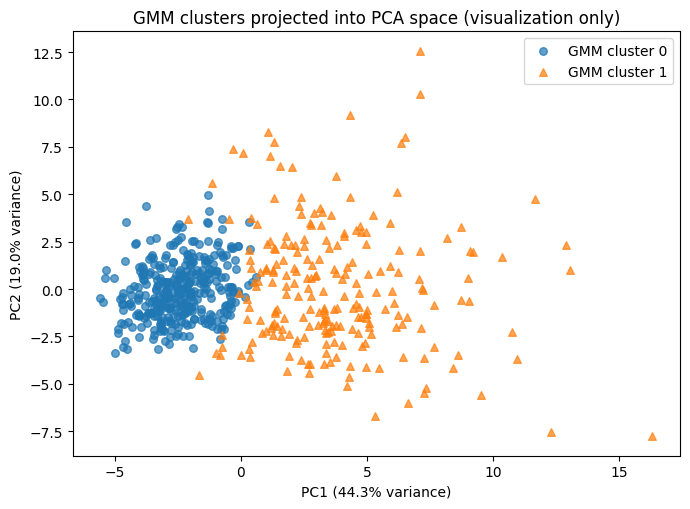

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_
print(f'PC1 explains {var[0]:.1%}; PC2 explains {var[1]:.1%}; together {var.sum():.1%}')

fig, ax = plt.subplots(figsize=(7,5.2))
markers = {0:'o', 1:'^'}
for c in np.unique(clusters):
    m = clusters == c
    ax.scatter(X_pca[m,0], X_pca[m,1], s=30, alpha=.70, marker=markers[c], label=f'GMM cluster {c}')
ax.set_xlabel(f'PC1 ({var[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({var[1]:.1%} variance)')
ax.set_title('GMM clusters projected into PCA space (visualization only)')
ax.legend(); plt.tight_layout(); plt.show()


## 11. Final result — what I would report
**Random Forest:** excellent held-out discrimination on this split (accuracy ≈ **97.4%**, ROC-AUC ≈ **0.997**), with **3 malignant false negatives** and no benign false positives. Size- and concavity-related measurements, particularly several `worst` features, contribute strongly to prediction.

**GMM:** without using diagnosis during fitting, a two-component model produces groups that correspond substantially to benign/malignant status (ARI ≈ **0.678**), but the overlap and silhouette ≈ **0.316** show that diagnosis is not simply two perfectly separated Gaussian clouds. BIC/AIC also indicate richer heterogeneity than two components in the tested range.

### Limitations I should mention
- 569 samples is useful but still a relatively small single dataset.
- The Random Forest result is from one held-out split; there is no external clinical validation here.
- Feature importance is predictive, not causal, and correlated variables can share importance.
- GMM results depend on scaling, covariance assumptions and number of components.
- This is a machine-learning analysis of a benchmark dataset, **not a clinical diagnostic tool**.
